# ***Netflix Recommendations***

📺 Netflix: A Brief Overview
Netflix, Inc. is a leading global streaming entertainment service that was founded in 1997 by Reed Hastings and Marc Randolph in California, USA. Originally a DVD rental service, Netflix transitioned to a subscription-based streaming platform in 2007, revolutionizing how people consume media content.

As of now, Netflix has over 260 million subscribers in 190+ countries, offering a vast library of movies, TV shows, documentaries, and original content across multiple genres and languages. It has become a powerhouse in content creation, producing critically acclaimed originals like Stranger Things, The Crown, Money Heist, and Squid Game.

- **Founded**: August 29, 1997

- **Headquarters**: Los Gatos, California, USA

- **Subscribers (2024)**: ~260 million

- **Business Model**: Subscription-based video-on-demand (SVOD)

- **Core Features**: Personalized recommendations, binge-watching support, mobile downloads, and multiple pricing tiers.

- **Technology**: Uses data-driven algorithms for content recommendations and user engagement. Also heavily relies on cloud computing and machine learning.

### Questions to Answer


1. What is the most frequent genre of movies released on Netflix?
2. Which has highest votes in vote avg column?
3. What movie got the highest popularity? what's its genre?
4. What movie got the lowest popularity? what's its genre?
5. Which year has the most filmmed movies?


### Lets Begin

We’re beginning our project with the essential step of data cleaning and preprocessing 🧹. This involves handling missing values, correcting inconsistencies, and transforming the data into a suitable format for analysis. A well-prepared dataset sets the stage for accurate insights and effective modeling

In [334]:
# importing data from csv file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [335]:
data=pd.read_csv('D:\\Netflix lets recommend\\data\\mymoviedb.csv',lineterminator='\n')

In [336]:
data.shape

(9827, 9)

In [337]:
data.head(5)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [338]:
data.isna().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

In [339]:
data.dtypes

Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count             int64
Vote_Average         float64
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object

In [340]:
data['Release_Date']=pd.to_datetime(data['Release_Date'],format='%Y-%m-%d')

#### ***Data Binning***

In [341]:
bins=np.linspace(data['Vote_Average'].min(),data['Vote_Average'].max(),4)
label=['Least','Average','Highly']


In [342]:
data['Recommended']=pd.cut(data['Vote_Average'],bins,labels=label)

### ***Most Frequent Genre of Movies on Netflix***

In [343]:
split_generes=data['Genre'].str.split(',').to_list()

In [344]:
def check(split_generes):
    dict={}
    for val in split_generes:
       for v in val:
        if v not in dict:
         dict[v]=1
        else :
         dict[v]+=1
    return dict

In [345]:
most_frequent_genere=check(split_generes)

In [346]:
most_frequent=pd.DataFrame({'Genre':most_frequent_genere.keys(),'Count':most_frequent_genere.values()})

In [347]:
def handle(value):
    value=value.strip()
    return value

In [348]:
most_frequent['Genre']=most_frequent['Genre'].apply(handle)

In [349]:
top_genres=most_frequent.groupby('Genre')['Count'].sum().reset_index().sort_values(by=['Count'],ascending=False)

Text(0, 0.5, 'Frequency')

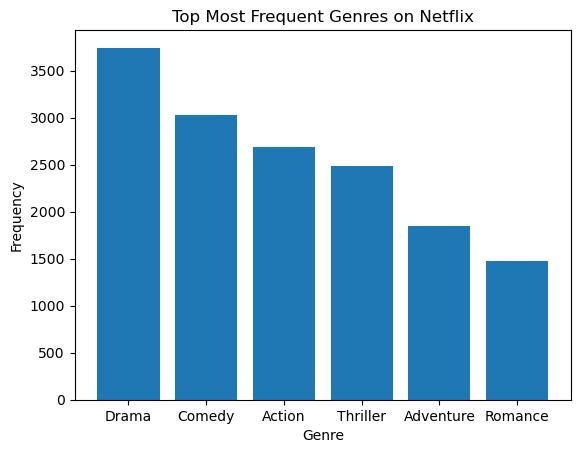

In [350]:
plt.bar(top_genres['Genre'].values.tolist()[0:6],top_genres['Count'].values.tolist()[0:6])
plt.title('Top Most Frequent Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Frequency')

In [351]:
print('Top 10 Genres of movies on netflix:')
for i,genre in enumerate(top_genres['Genre'].values.tolist()[0:10]):
    print(f'{i+1}){genre}')

Top 10 Genres of movies on netflix:
1)Drama
2)Comedy
3)Action
4)Thriller
5)Adventure
6)Romance
7)Horror
8)Animation
9)Family
10)Fantasy


### ***🎬 Genre Popularity Analysis on Netflix***
**An in-depth analysis of the genre distribution reveals fascinating insights into viewer preferences on Netflix. Drama stands tall as the most-watched genre, capturing audiences with its powerful storytelling and emotional depth. Not far behind, Comedy and Action dominate the charts, offering viewers both laughter and adrenaline-pumping excitement. The popularity of Thriller, Adventure, and Romance further emphasizes the audience’s love for suspenseful plots, gripping journeys, and heartfelt connections. Interestingly, genres like Horror, Animation, Family, and Fantasy also secured their spots in the top 10, showcasing the platform’s broad appeal across age groups and interests. This diverse genre landscape highlights how Netflix successfully caters to a wide spectrum of moods and moments, making it a go-to hub for global entertainment lovers**

### ***Top  Voted Movies*** 

In [352]:
top_rated_movies=data.sort_values(by=['Vote_Average'],ascending=False)

Text(0, 0.5, 'Frequency')

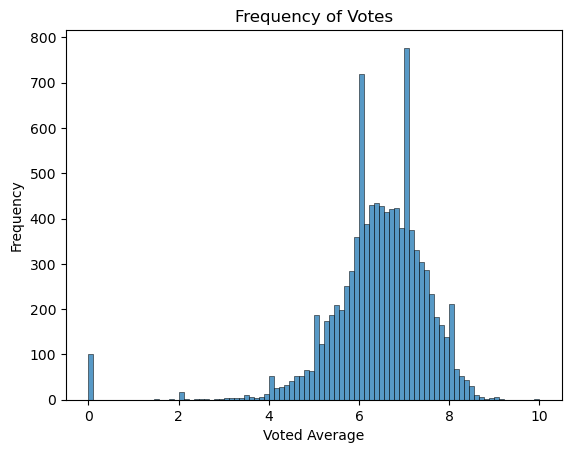

In [353]:
sns.histplot(data['Vote_Average'])
plt.title('Frequency of Votes')
plt.xlabel('Voted Average')
plt.ylabel('Frequency')

### 🎯 Analysis of Movie Ratings Distribution

The histogram above illustrates the distribution of average ratings (voted averages) received by movies on the platform. Several key observations can be drawn:

- 📌 **Majority of movies received ratings between 6 and 8**, with a significant peak around 7, indicating that most movies are perceived as above average by viewers.
- 🎯 A **very small number of movies received a perfect rating of 10**, highlighting how rare top-rated films are.
- ⚠️ Interestingly, there is a **notable spike at rating 0**, with approximately 100 movies having a zero average vote. This may suggest missing or unregistered ratings rather than actual viewer scores.
- 📉 The **least number of movies were rated 9**, which stands out as an uncommon rating despite being close to perfect.
- ✅ Overall, **most movies have an average rating above 6**, suggesting a generally favorable reception across the board.

This distribution helps identify audience sentiment and quality trends within the platform's movie catalog.


In [354]:
# Top rated Movies 
movies={
    'Movie Name':top_rated_movies['Title'].values.tolist()[0:10],
    'Ratings':top_rated_movies['Vote_Average'].values.tolist()[0:10]
}

In [355]:
result=pd.DataFrame(movies)

#### 🎬 Top Rated Movies on Netflix

Netflix continues to deliver a diverse mix of highly rated content, catering to global audiences with varied tastes. Here's a curated list of **top-rated movies** currently trending on the platform:

<ol>
  <li><strong>Kung Fu Master Huo Yuanjia</strong> – A gripping martial arts biopic that pays homage to a legendary Chinese fighter.</li>
  <li><strong>Franco Escamilla: Por La Anécdota</strong> – A laugh-out-loud stand-up special from the iconic Mexican comedian.</li>
  <li><strong>Demon Slayer: Kimetsu no Yaiba – Sibling's Bond</strong> – An emotionally charged anime masterpiece featuring action and heartwarming family ties.</li>
  <li><strong>Impossible Things</strong> – A heartfelt drama exploring the power of human connection and healing.</li>
  <li><strong>My Sex Doll</strong> – A quirky and unexpected story that combines comedy and sci-fi in a unique narrative.</li>
  <li><strong>Sex School: Dorms of Desire</strong> – A bold and provocative drama pushing boundaries on adult education and relationships.</li>
  <li><strong>Mission «Sky»</strong> – A high-octane thriller that takes you on an intense military rescue operation.</li>
  <li><strong>The Three Deaths of Marisela Escobedo</strong> – A powerful documentary uncovering the truth behind a mother’s courageous fight for justice.</li>
  <li><strong>Bring the Soul: The Movie</strong> – A behind-the-scenes look into the lives of BTS members, blending concert footage with personal reflections.</li>
  <li><strong>Ni tuyo, Ni mía</strong> – A romantic comedy that dives into love, identity, and unexpected relationships in modern times.</li>
</ol>

These selections reflect Netflix's commitment to offering something for everyone — whether you're into action, anime, comedy, or documentaries.


### ***Movies with Highest Popularity***

In [356]:
# Popular movies with high popularity
top_popular_movies=data.sort_values(by=['Popularity'],ascending=False)

In [357]:
# List of top 10 popular movies
top_10_popular=top_popular_movies['Title'].values.tolist()[0:10]

In [358]:
# Least Popular movies 
top_least_popular_movies=data.sort_values(by=['Popularity'])

In [359]:
# Top 10 Least Popular movies
top_10_least_popular_movies=top_least_popular_movies['Title'].values.tolist()[0:10]

In [360]:
data['Popularity'].mean()

40.32608822631525

Text(0, 0.5, 'Frequency')

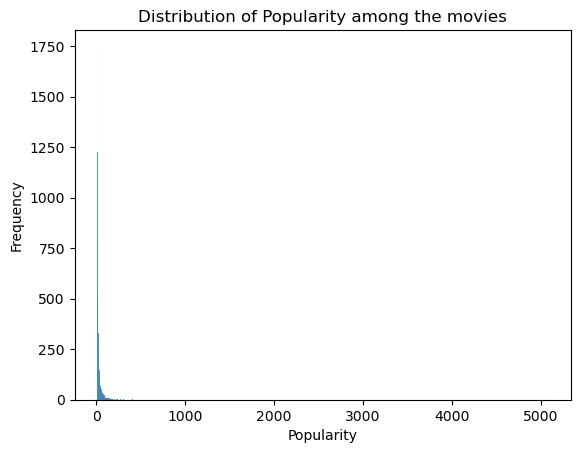

In [361]:
# Plot a histplot to understand the frequency distribution of popularity of movies
sns.histplot(data['Popularity'])
plt.title('Distribution of Popularity among the movies')
plt.xlabel('Popularity')
plt.ylabel('Frequency')

##### 📊 Popularity Distribution Among Movies

From the graph, it's evident that **most movies have a popularity score ranging between 0 and 1000**, indicating that the majority receive moderate to low viewer engagement. However, there are a **few outliers with exceptionally high popularity**, making them stand out significantly from the rest. These rare cases likely represent blockbuster hits or globally trending content.


##### 🌟 Top 10 Highly Popular Movies on Netflix

Netflix offers a thrilling lineup of blockbuster hits that have captured global attention. Here are the top 10 movies that have gained massive popularity on the platform:

<ol>
  <li><strong>Spider-Man: No Way Home</strong> – A multiverse spectacle that brings together generations of Spider-Man fans.</li>
  <li><strong>The Batman</strong> – A dark, gritty reboot of the caped crusader with a compelling narrative and noir style.</li>
  <li><strong>No Exit</strong> – A suspense-packed thriller with twists that keep you on the edge of your seat.</li>
  <li><strong>Encanto</strong> – A magical animated musical that celebrates Colombian culture and family bonds.</li>
  <li><strong>The King's Man</strong> – A high-octane origin story of the elite spy organization with historical twists.</li>
  <li><strong>The Commando</strong> – An action-packed ride featuring intense combat and gripping tension.</li>
  <li><strong>Scream</strong> – The classic slasher returns with a modern edge and nostalgic callbacks.</li>
  <li><strong>Kimi</strong> – A tech-thriller that dives into surveillance, privacy, and mystery in a connected world.</li>
  <li><strong>Fistful of Vengeance</strong> – Martial arts, supernatural forces, and revenge combine in this adrenaline-fueled movie.</li>
  <li><strong>Eternals</strong> – A Marvel epic introducing immortal heroes who shape the fate of humanity.</li>
</ol>

These titles reflect not just high viewership but also strong engagement, making them the most talked-about films on Netflix recently.


##### 💤 Top 10 Least Popular Movies on Netflix

While Netflix boasts a vast and diverse library, not all titles receive the same level of attention. Below are the **10 least popular movies** on the platform based on viewership and engagement metrics:

<ol>
  <li><strong>Threads</strong> – A grim and haunting depiction of nuclear war that remains overlooked by mainstream audiences.</li>
  <li><strong>The United States vs. Billie Holiday</strong> – Despite its historical significance, it hasn't resonated widely with Netflix viewers.</li>
  <li><strong>The Offering</strong> – A horror film that seems to have flown under the radar.</li>
  <li><strong>Violent Delights</strong> – Lacking broad appeal, this title struggled to find its audience.</li>
  <li><strong>The Little Prince</strong> – A beautifully made adaptation that surprisingly didn’t gain much traction.</li>
  <li><strong>Badlands</strong> – A cult classic with limited reach among modern Netflix users.</li>
  <li><strong>Unlawful Entry</strong> – A 90s thriller that hasn't maintained popularity in today’s streaming world.</li>
  <li><strong>Amateur Porn Star Killer 2</strong> – Highly niche and controversial, resulting in minimal engagement.</li>
  <li><strong>All Is Lost</strong> – A survival drama praised by critics but underwatched by general audiences.</li>
  <li><strong>I'm in Love With My Little Sister</strong> – A provocative anime with extremely limited appeal.</li>
</ol>

These films represent titles that, for various reasons—niche genre, minimal promotion, or controversial themes—remain largely unseen on the platform.


### Feature Engineering

In [362]:
def get_year(year):
    value=str(year)
    return value[0:4]

In [363]:
year=data['Release_Date'].apply(get_year)

In [364]:
data['Release-Year']=year

In [365]:
data['Release-Year']=data['Release-Year'].astype(int)

### Year with lots of movies 

In [366]:
movies_every_year=data['Release-Year'].value_counts().reset_index()

In [367]:
movies_every_year=movies_every_year.sort_values(by=['count'],ascending=False).reset_index()

Text(0, 0.5, 'Number of movies released')

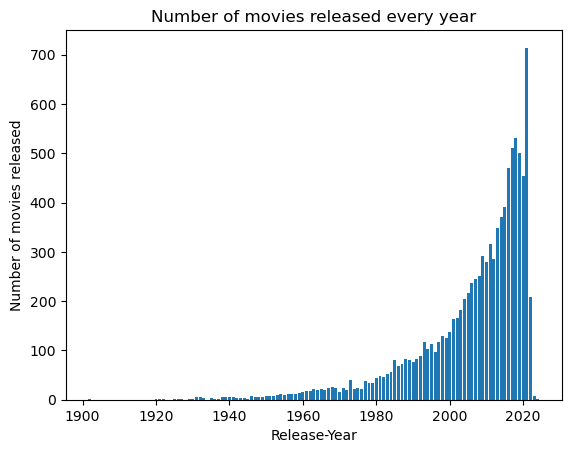

In [368]:
# Number of movies released in certain years
plt.bar(movies_every_year['Release-Year'],movies_every_year['count'])
plt.title('Number of movies released every year')
plt.xlabel('Release-Year')
plt.ylabel('Number of movies released')

#### 📊 Insights from Movie Release Trends (1900–2022)

From the bar chart above, we observe a **steady increase in the number of movies released each year** from the early 1900s, with a sharp rise starting in the 1980s. This trend highlights the rapid growth of the global film industry, driven by advancements in technology, streaming platforms, and audience demand.

However, there's a **significant drop around 2020**, which aligns with the outbreak of **COVID-19**. The global pandemic led to lockdowns, halted productions, and delayed releases—causing a noticeable dip in movie releases during that period.

---

#### 📝 Key Observations:
- 📈 Steady growth in movie releases from 1980 to 2019  
- 📉 Sudden fall around 2020 due to the pandemic  
- 🎬 Recovery begins in 2021 with a spike in releases as restrictions ease


#### 🏆 Peak Year for Releases

Interestingly, **2021 saw the highest number of movie releases**, with a total of **714 films**. This surge could be attributed to the backlog of movies postponed during the 2020 lockdown, as well as the rise of OTT platforms accelerating digital releases. It reflects the industry's adaptation and recovery post-pandemic.


## ***Model Development***

#### 🎬 Model Development: Predicting `Vote_Average` from `Popularity` and `Vote_Count`

To understand how audience engagement influences movie ratings, we build a regression model to **predict `Vote_Average`** using two key features:

- 📈 **Popularity** – Measures how much attention a movie is getting.
- 🗳️ **Vote_Count** – Indicates how many people have rated the movie.

In [369]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

In [370]:
# Seelecting the only required columns to train model
columns_to_train_model=data.select_dtypes(include=['int64','float64'])[['Vote_Average','Popularity','Vote_Count']].reset_index()

In [371]:
# Lets See the coorelation between the variables
corr,p_value=pearsonr(columns_to_train_model['Popularity'],columns_to_train_model['Vote_Average'])
print(f'Correation between columnns popularity and vote_average is {corr} and p_value is {p_value}')

Correation between columnns popularity and vote_average is 0.053843990775950215 and p_value is 9.252906355913223e-08


In [372]:
# Lets See the coorelation between the variables
corr,p_value=pearsonr(columns_to_train_model['Vote_Count'],columns_to_train_model['Vote_Average'])
print(f'Correation between columnns vote_count and vote_average is {corr} and p_value is {p_value}')

Correation between columnns vote_count and vote_average is 0.25357376045633956 and p_value is 5.134562621925813e-144


Text(0, 0.5, 'Popularity')

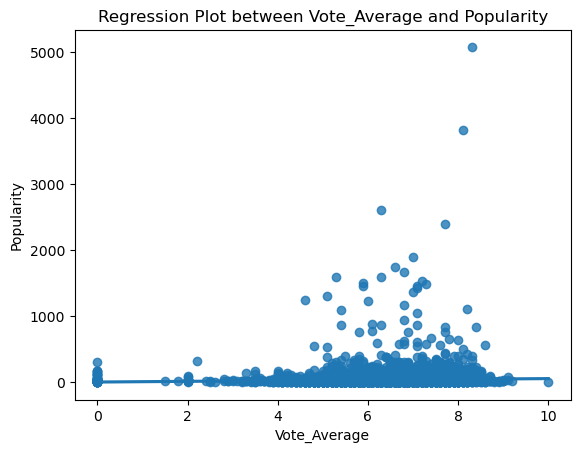

In [373]:
# Lets Plot regression plots for better understanding
sns.regplot(x='Vote_Average',y='Popularity',data=columns_to_train_model)
plt.title('Regression Plot between Vote_Average and Popularity')
plt.xlabel('Vote_Average')
plt.ylabel('Popularity')

Text(0, 0.5, 'Popularity')

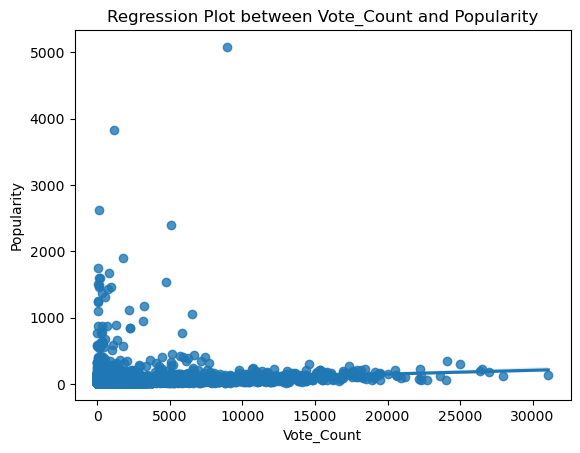

In [374]:
# Lets Plot regression plots for better understanding
sns.regplot(x='Vote_Count',y='Popularity',data=columns_to_train_model)
plt.title('Regression Plot between Vote_Count and Popularity')
plt.xlabel('Vote_Count')
plt.ylabel('Popularity')

### 📊 Insights from Regression Analysis

The regression plots reveal a **slight positive correlation** between both `Popularity` and `Vote_Count` with `Vote_Average`. However, the relationships are **not strong**, and both features display a wide spread of values and outliers. 

This suggests that while these variables may have some predictive power, they **should not be relied upon individually** to accurately predict `Vote_Average`. Combining them with additional features might lead to better model performance.


In [375]:
# Multiple regression to predict vote_average using popularity and vote_count
lr=LinearRegression()

In [376]:
# Spliting data for training and testing
xtrain,xtest,ytrain,ytest=train_test_split(columns_to_train_model[['Popularity','Vote_Count']],columns_to_train_model['Vote_Average'],test_size=0.2,random_state=42)

In [377]:
# Fit the model with training data 
lr.fit(xtrain,ytrain)

LinearRegression()

In [378]:
# Prediction using training data 
predict=lr.predict(xtrain)

In [379]:
# Prediction using testing data 
predict_test=lr.predict(xtest)

In [380]:
# Accuracy of model using trained data
print(f'Multple regression (Train Data) r2 score and mean squared error {round(lr.score(xtrain,ytrain),3)},{round(mean_squared_error(ytrain,predict),3)}')

Multple regression (Train Data) r2 score and mean squared error 0.065,1.174


In [381]:
# Accuracy of model using testing data
print(f'Multple regression (Test Data) r2 score and mean squared error {round(lr.score(xtest,ytest),3)},{round(mean_squared_error(ytest,predict_test),3)}')

Multple regression (Test Data) r2 score and mean squared error 0.064,1.274


#### 📉 Model Evaluation Summary

The multiple linear regression model was trained using `Vote_Count` and `Popularity` to predict `Vote_Average`. While the model ran without issues and demonstrated **consistent performance** across training and testing sets, the results were not promising in terms of accuracy:

- **Train R² Score:** 0.065 | **MSE:** 1.174  
- **Test R² Score:** 0.064 | **MSE:** 1.274

🔍 **Key Insight:**  
The very low R² scores indicate that the model explains only about **6% of the variance** in `Vote_Average`. This aligns with earlier regression plots that showed **weak correlations** between the features and the target variable.

⚠️ **Conclusion:**  
Although the model is stable (i.e., not overfitting or underfitting), it is **not effective** at predicting `Vote_Average` using only `Vote_Count` and `Popularity`. Additional or alternative features are required for building a more accurate prediction model.


### ***🎥 Content-Based Movie Recommender System***

We’ll recommend movies based on their description (overview) using text similarity.



In [392]:
# importing required libraries
from sklearn.feature_extraction.text import TfidfVectorizer # For converting text to numbers
from sklearn.metrics.pairwise import cosine_similarity # For Finding Similar Movies
import joblib

In [383]:
df=data[['Title','Overview']]
df=df.dropna()

In [384]:
tfidf=TfidfVectorizer(stop_words='english') # Removes Common words like 'the','is','this',etc.
tfidf_matrix=tfidf.fit_transform(df['Overview']) # Create TF-IDF matrix

***Computers can’t understand raw text — so we convert the overview into a vector using TF-IDF:***

- **TF = Term Frequency (how often a word appears in a document)**

- **IDF = Inverse Document Frequency (how rare a word is across all documents**

In [385]:
# Calculating similarity between all movies
cosine_sim=cosine_similarity(tfidf_matrix,tfidf_matrix)

This creates a matrix showing how similar each movie is to every other movie based on their overviews. Higher the score, more similar they are (score ranges from 0 to 1).



In [387]:
indices = pd.Series(df.index, index=df['Title']).drop_duplicates()

In [389]:
def get_recommendations(title, cosine_sim=cosine_sim):
    if title not in indices:
        return "Movie not found. Please check the spelling."
    
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]

    return df['Title'].iloc[movie_indices]


In [390]:
recommended_movies=get_recommendations('Kung Fu Panda')

In [ ]:
joblib.dump(tfidf_matrix,'TF-IDF-Vectorizer.pkl')
joblib.dump(cosine_sim,'Cosine-Similarity.pkl')

['Cosine-Similarity.joblib']

## 📐 Mathematics Behind the Recommendation Engine

### 1. TF-IDF Vectorization

TF-IDF stands for **Term Frequency - Inverse Document Frequency**. It helps convert text into numerical vectors by assigning weights to words based on how important they are.

- **Term Frequency (TF):**

$$
TF(t) = \frac{\text{Number of times term } t \text{ appears in a document}}{\text{Total terms in the document}}
$$

- **Inverse Document Frequency (IDF):**

$$
IDF(t) = \log \left( \frac{N}{df(t)} \right)
$$

Where:
- \( N \): Total number of documents (movies)
- \( df(t) \): Number of documents containing the term \( t \)

- **TF-IDF Score:**

$$
\text{TF-IDF}(t, d) = TF(t, d) \times IDF(t)
$$

---

### 2. Cosine Similarity

To measure how similar two movies are based on their overview:

$$
\text{Cosine Similarity}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}
$$

Where:
- \( A  \\cdot B \) is the dot product
- \( \|A\| \), \( \|B\| \) are the magnitudes (lengths) of the vectors

A value close to **1** means **high similarity**.

---

### 🔁 Summary

- **TF-IDF** turns text into a weighted vector
- **Cosine similarity** compares the angle between vectors to find similar movies
